In [23]:
# Library Manipulasi Data
import numpy as np
import pandas as pd

# Library Visualisasi
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Library Sistem & File
import kagglehub
import os
from google.colab import files

# Library Machine Learning (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Deep Learning Framework
import tensorflow as tf
import keras

# Preprocessing Citra
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import cv2

# Arsitektur Model (Pretrained CNN)
from tensorflow.keras.applications import MobileNet

# Komponen Model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout

# Optimizer & Regularisasi
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.regularizers import l2

In [3]:
# Download Dataset dari Kaggle
path = kagglehub.dataset_download("fatemehmehrparvar/lung-disease")
print("Path to dataset files:", path)

#
parent_dir = os.path.join(path, "Lung X-Ray Image", "Lung X-Ray Image")

Lung_Opacity = os.path.join(parent_dir, "Lung_Opacity")
Normal = os.path.join(parent_dir, "Normal")
Viral_Pneumonia = os.path.join(parent_dir, "Viral Pneumonia")
file_p = []
labels = []
dict_lists = [Normal, Lung_Opacity, Viral_Pneumonia]
class_labels = ['Normal', 'Lung Opacity','Viral Pneumonia']

for i, dir_path in enumerate(dict_lists):
  # dir_path is already the full path to the directory
  list_f = os.listdir(dir_path)
  for name in list_f:
    fpath = os.path.join(dir_path, name)
    file_p.append(fpath)
    labels.append(class_labels[i])

file_path = pd.Series(file_p, name="filepaths")
Labels = pd.Series(labels, name="labels")
data = pd.concat([file_path, Labels], axis=1)
df = pd.DataFrame(data)

print("Lung Opacity Path:", Lung_Opacity)
print("Normal Path:", Normal)
print("Viral Pneumonia Path:", Viral_Pneumonia)

100%|██████████| 34.9M/34.9M [00:00<00:00, 158MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1
Lung Opacity Path: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1/Lung X-Ray Image/Lung X-Ray Image/Lung_Opacity
Normal Path: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1/Lung X-Ray Image/Lung X-Ray Image/Normal
Viral Pneumonia Path: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1/Lung X-Ray Image/Lung X-Ray Image/Viral Pneumonia


In [4]:
df

,filepaths,labels
0,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
1,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
2,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
3,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
4,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
...,...,...
3470,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia
3471,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia
3472,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia
3473,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia


In [5]:
# Division: 70% Train, 30% Remaining (for Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['labels'], random_state=42)
# Division of the Remaining (30%) into two: 15% Val and 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)
# This parameter ensures that the class proportions are the same as in the original data.
print("Train df shape:", train_df.shape)
print("Test df shape:", test_df.shape)
print("Val df shape:", val_df.shape)

Train df shape: (2432, 2)
Test df shape: (522, 2)
Val df shape: (521, 2)


In [6]:
def enhance_image(image):
  image = cv2.addWeighted(image, 1.5, image, -0.5, 0)

  kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
  image = cv2.filter2D(image, -1, kernel)

  hue = image[:, :, 0]
  saturation = image[:, :, 1]
  value = image[:, :, 2]
  value = np.clip(value * 1.25, 0, 255)

  image[:, :, 2] = value

  return image

In [12]:
batch_size = 32

image_gen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda image: enhance_image(image))
train = image_gen.flow_from_dataframe(dataframe= train_df,x_col="filepaths",y_col="labels",
                                      target_size=(256,256),
                                      color_mode='rgb',
                                      class_mode="categorical",
                                      batch_size=batch_size,
                                      shuffle=False
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_df,x_col="filepaths", y_col="labels",
                                     target_size=(256,256),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=batch_size,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_df,x_col="filepaths", y_col="labels",
                                    target_size=(256,256),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=batch_size,
                                    shuffle=False
                                   )

Found 2432 validated image filenames belonging to 3 classes.
Found 522 validated image filenames belonging to 3 classes.
Found 521 validated image filenames belonging to 3 classes.


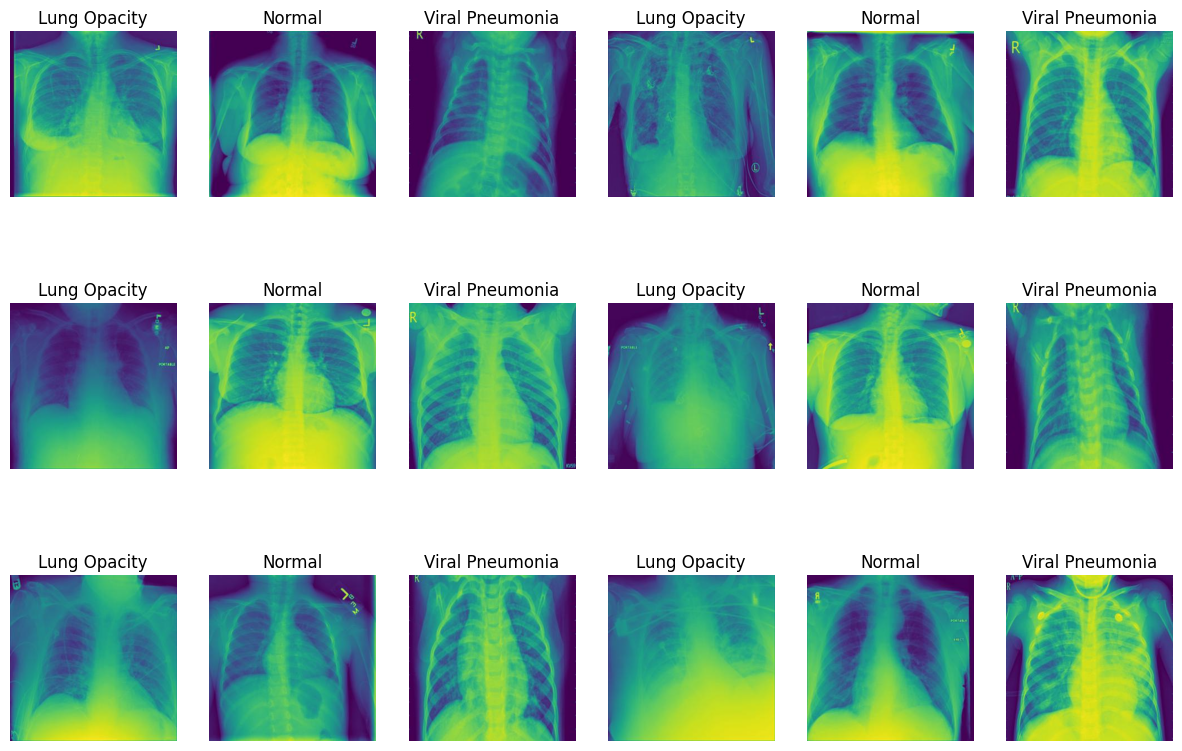

In [9]:
import matplotlib.pyplot as plt

# Define the number of images to display from each class
num_images_per_class = 6

# Get class labels
class_labels = list(train.class_indices.keys())

# Plot images from each class
plt.figure(figsize=(15, 10))
for label in class_labels:
  # Get indices of images belonging to the current class
  indices = train_df[train_df['labels'] == label].index

  # Randomly sample a subset of indices if there are more than the desired number of images per class
  indices = np.random.choice(indices, min(num_images_per_class, len(indices)), replace=False)

  # Plot images
  for i, idx in enumerate(indices):
    plt.subplot(len(class_labels), num_images_per_class, len(class_labels)*i + class_labels.index(label) + 1)
    plt.imshow(plt.imread(train_df.loc[idx, 'filepaths']))  # Load and plot the image
    plt.title(label)
    plt.axis('off')
plt.show()


In [15]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adamax

# Load pre-trained MobileNet model without the top (fully connected) layers
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3),pooling='max')

# Add custom top layers for your specific task
x = base_model.output
x = BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.45)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

learning_rate = 0.001
epochs = 30
optimizer = Adamax(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train, epochs=30, validation_data=val)

/tmp/ipykernel_572/3663344249.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3),pooling='max')


Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 70s 359ms/step - accuracy: 0.8294 - loss: 0.4775 - val_accuracy: 0.7505 - val_loss: 0.6284
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.9231 - loss: 0.2070 - val_accuracy: 0.8714 - val_loss: 0.3799
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.9650 - loss: 0.1007 - val_accuracy: 0.9060 - val_loss: 0.2868
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - accuracy: 0.9856 - loss: 0.0456 - val_accuracy: 0.9232 - val_loss: 0.2475
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.9934 - loss: 0.0209 - val_accuracy: 0.9271 - val_loss: 0.2864
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.9984 - loss: 0.0114 - val_accuracy: 0.9251 - val_loss: 0.3004
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.9309 - val_loss: 0.2978
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accu

In [17]:
import time

start_time = time.time()
loss1, accuracy1 = model.evaluate(test)
end_time = time.time()

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}","\n")

print("Test Loss:", loss1)
print("Test Accuracy:", accuracy1)
print(f"Evaluation Time: {end_time - start_time:.2f} seconds")

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.9215 - loss: 0.4372
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.001
Epoch: 30 

Test Loss: 0.4372496008872986
Test Accuracy: 0.9214559197425842
Evaluation Time: 2.61 seconds


In [20]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Get class names from the test generator
class_names = list(test.class_indices.keys())

# Generate and print the classification report
report = classification_report(true_classes, y_pred_classes, target_names=class_names, digits=3)
print("Classification Report:")
print(report)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
Classification Report:
                 precision    recall  f1-score   support

   Lung Opacity      0.895     0.905     0.900       169
         Normal      0.907     0.883     0.895       188
Viral Pneumonia      0.964     0.982     0.973       165

       accuracy                          0.921       522
      macro avg      0.922     0.923     0.923       522
   weighted avg      0.921     0.921     0.921       522



17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step


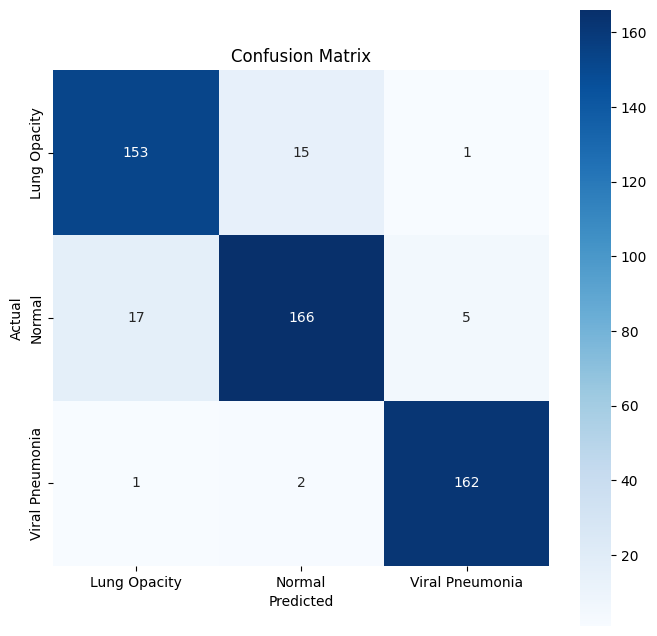

In [19]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes, y_pred_classes)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=test.class_indices.keys(), yticklabels=test.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
learning_rate = 0.01
epochs = 30
optimizer = Adamax(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model.fit(train, epochs=30, validation_data=val)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 296ms/step - accuracy: 0.8026 - loss: 0.7726 - val_accuracy: 0.3820 - val_loss: 4.5825
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.8861 - loss: 0.3249 - val_accuracy: 0.7716 - val_loss: 0.6263
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.9153 - loss: 0.2303 - val_accuracy: 0.6564 - val_loss: 1.0307
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.9231 - loss: 0.2096 - val_accuracy: 0.8887 - val_loss: 0.2806
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.9486 - loss: 0.1510 - val_accuracy: 0.8925 - val_loss: 0.3797
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.9544 - loss: 0.1265 - val_accuracy: 0.8445 - val_loss: 0.5355
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.9601 - loss: 0.1098 - val_accuracy: 0.9040 - val_loss: 0.3386
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.9704 - loss: 0.0909 - val_accu

In [34]:
import time

start_time = time.time()
loss2, accuracy2 = model.evaluate(test)
end_time = time.time()

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}","\n")

print("Test Loss:", loss2)
print("Test Accuracy:", accuracy2)
print(f"Evaluation Time: {end_time - start_time:.2f} seconds")

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.9042 - loss: 0.6849
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.01
Epoch: 30 

Test Loss: 0.6848517060279846
Test Accuracy: 0.9042145609855652
Evaluation Time: 5.27 seconds


In [35]:
# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Get class names from the test generator
class_names = list(test.class_indices.keys())

# Generate and print the classification report
report = classification_report(true_classes, y_pred_classes, target_names=class_names, digits=3)
print("Classification Report:")
print(report)

17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step
Classification Report:
                 precision    recall  f1-score   support

   Lung Opacity      0.851     0.911     0.880       169
         Normal      0.912     0.824     0.866       188
Viral Pneumonia      0.953     0.988     0.970       165

       accuracy                          0.904       522
      macro avg      0.905     0.908     0.905       522
   weighted avg      0.905     0.904     0.903       522



17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step


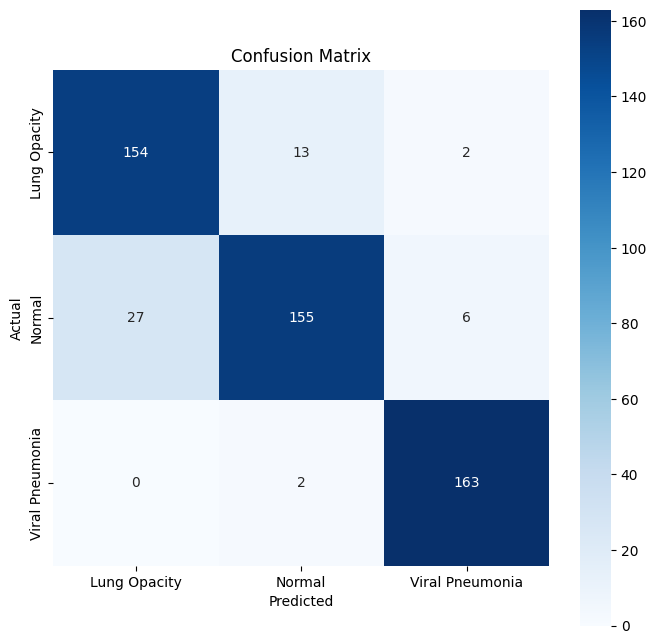

In [36]:
# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes, y_pred_classes)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=test.class_indices.keys(), yticklabels=test.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [40]:
learning_rate = 0.0001
epochs = 30
optimizer = Adamax(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history3 = model.fit(train, epochs=epochs, validation_data=val)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 256ms/step - accuracy: 0.9947 - loss: 0.0189 - val_accuracy: 0.9136 - val_loss: 0.6654
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.9979 - loss: 0.0077 - val_accuracy: 0.9194 - val_loss: 0.6543
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9984 - loss: 0.0078 - val_accuracy: 0.9232 - val_loss: 0.6543
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9996 - loss: 0.0029 - val_accuracy: 0.9232 - val_loss: 0.6545
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.9996 - loss: 0.0048 - val_accuracy: 0.9213 - val_loss: 0.6554
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9232 - val_loss: 0.6556
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9232 - val_loss: 0.6550
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accu

In [41]:
start_time = time.time()
loss3, accuracy3 = model.evaluate(test)
end_time = time.time()

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}","\n")

print("Test Loss:", loss3)
print("Test Accuracy:", accuracy3)
print(f"Evaluation Time: {end_time - start_time:.2f} seconds")

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 323ms/step - accuracy: 0.9100 - loss: 0.7195
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.0001
Epoch: 30 

Test Loss: 0.7195143103599548
Test Accuracy: 0.9099617004394531
Evaluation Time: 5.59 seconds


In [42]:
# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Get class names from the test generator
class_names = list(test.class_indices.keys())

# Generate and print the classification report
report = classification_report(true_classes, y_pred_classes, target_names=class_names, digits=3)
print("Classification Report:")
print(report)

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 350ms/step
Classification Report:
                 precision    recall  f1-score   support

   Lung Opacity      0.888     0.888     0.888       169
         Normal      0.890     0.856     0.873       188
Viral Pneumonia      0.953     0.994     0.973       165

       accuracy                          0.910       522
      macro avg      0.910     0.913     0.911       522
   weighted avg      0.909     0.910     0.909       522



17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


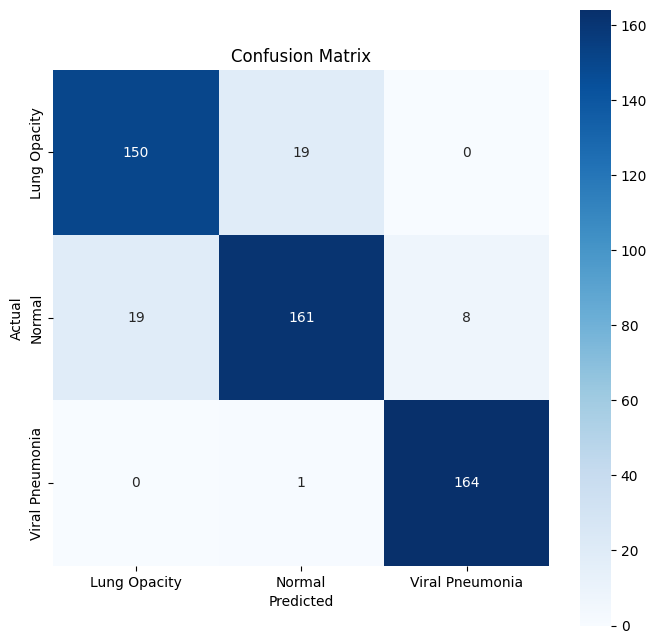

In [43]:
# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes, y_pred_classes)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=test.class_indices.keys(), yticklabels=test.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def predict_with_upload(model, class_indices):
  # 1. Trigger fitur upload file
  uploaded = files.upload()

  for file_name in uploaded.keys():
    # 2. Load gambar asli untuk tampilan visual
    img = image.load_img(file_name, target_size=(256, 256))
    img_array = image.img_to_array(img)

    # Tambahkan dimensi batch (1, 224, 224, 3)
    img_ready = np.expand_dims(img_array, axis=0) # Use img_array directly

    # 3. Prediksi
    predictions = model.predict(img_ready)[0]
    class_names = list(class_indices.keys())

    # 4. Mengolah Hasil
    results = []
    for i in range(len(class_names)):
        results.append((class_names[i], predictions[i] * 100))

    # Sort dari persentase tertinggi
    results.sort(key=lambda x: x[1], reverse=True)

    # 5. Visualisasi (Hanya Original Image)
    plt.figure(figsize=(6, 6))

    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Tampilkan Teks Prediksi
    display_text = f"Top Result:\n {results[0][0]} ({results[0][1]:.4f}%)\n" # Changed to .4f
    for name, prob in results[1:]:
      display_text += f"{name}: {prob:.4f}%\n" # Changed to .4f

    plt.suptitle(display_text, fontsize=12)
    plt.tight_layout()
    plt.show()

# Cara Menjalankan:
predict_with_upload(model, train.class_indices)